In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [14]:
df_assess = pd.read_csv("final_assessment.csv")
df_grades = pd.read_csv("grades.csv")
df_status = pd.read_csv("status.csv")

In [15]:
display(df_assess.head())
display(df_grades.head())
display(df_status.head())

,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0
3,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0
4,11,1.00,3.0,1.0,2.0,1.0,0.0,1.0,2.0,1.0,3.0,1.0,5.0,1.0,4.0,1.0,3.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,3.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,0.0,2.0


,id,coding_score,handwritten_score,final_score,final_score_adj
0,0,NaN,NaN,0.737705,0.616393
1,1,0.928571,NaN,0.754098,0.639344
2,3,0.857143,1.0,0.836066,0.550820
3,9,0.904764,NaN,0.672131,0.511475
4,11,0.928571,1.0,0.918033,0.439344


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [16]:
df_status = df_status[df_status["completed"] == 1].copy()

print("Completed students:", df_status.shape[0])
display(df_status["section"].value_counts())

Completed students: 13


section
1    4
4    4
2    3
3    2
Name: count, dtype: int64

In [17]:
df_id = (
    df_grades
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("ID-level shape:", df_id.shape)
display(df_id.head())

ID-level shape: (13, 6)


,id,coding_score,handwritten_score,final_score,final_score_adj,section
0,0,NaN,NaN,0.737705,0.616393,1
1,1,0.928571,NaN,0.754098,0.639344,2
2,3,0.857143,1.0,0.836066,0.550820,4
3,9,0.904764,NaN,0.672131,0.511475,2
4,11,0.928571,1.0,0.918033,0.439344,4


In [18]:
df_item = (
    df_assess
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("Item-level shape:", df_item.shape)
display(df_item.head())

Item-level shape: (13, 38)


,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level,section
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0,1
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0,2
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0,4
3,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0,2
4,11,1.00,3.0,1.0,2.0,1.0,0.0,1.0,2.0,1.0,3.0,1.0,5.0,1.0,4.0,1.0,3.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,3.0,1.0,3.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,0.0,2.0,4


In [19]:
df_id["group"] = df_id["section"]
df_item["group"] = df_item["section"]

### 1. Final assessment scores by group（boxplot）

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\398131605.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


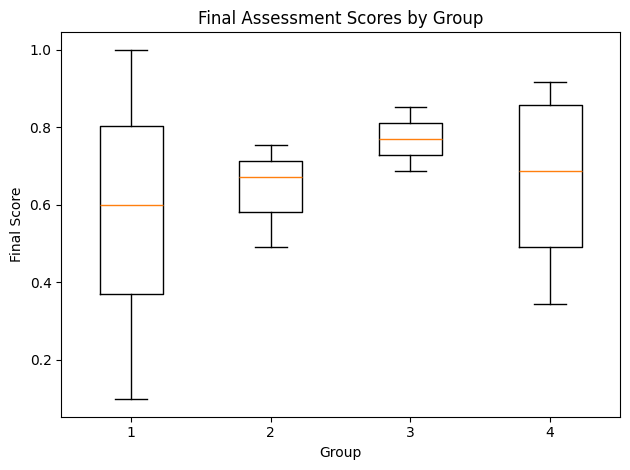

In [20]:
groups = sorted(df_id["group"].unique())
data = [df_id.loc[df_id["group"] == g, "final_score"] for g in groups]

plt.figure()
plt.boxplot(data, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score")
plt.title("Final Assessment Scores by Group")
plt.tight_layout()
plt.show()

### 2. Final assessment scores adjusted for confidence（boxplot）

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\3316147613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_adj, labels=groups, showfliers=False)


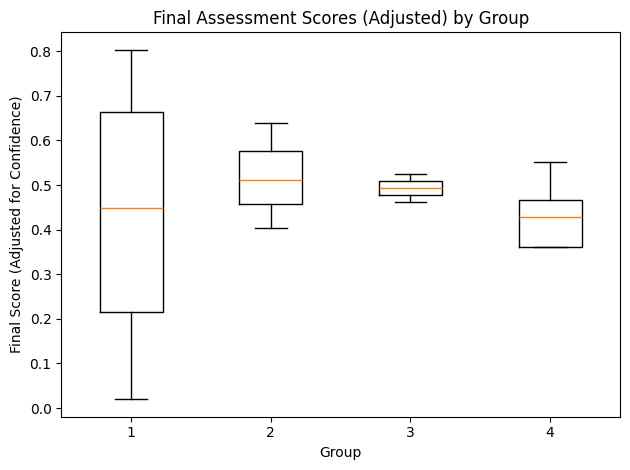

In [21]:
data_adj = [df_id.loc[df_id["group"] == g, "final_score_adj"] for g in groups]

plt.figure()
plt.boxplot(data_adj, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score (Adjusted for Confidence)")
plt.title("Final Assessment Scores (Adjusted) by Group")
plt.tight_layout()
plt.show()

### 3. Standard Deviations/Means by subquestion（rescaled 0–1）

In [28]:
score_cols = [c for c in df_item.columns if c.endswith("_score")]

print("Number of subquestions:", len(score_cols))
print(score_cols)

Number of subquestions: 18
['1.1_score', '1.2_score', '1.3_score', '1.4_score', '2.1_score', '2.2_score', '2.3_score', '2.4_score', '3.1_score', '3.2_score', '3.3_score', '3.4_score', '3.5_score', '4.1_score', '5.1_score', '5.2_score', '5.3_score', '5.4_score']


In [29]:
long_scores = (
    df_item[["id"] + score_cols]
    .melt(
        id_vars="id",
        value_vars=score_cols,
        var_name="subquestion",
        value_name="score"
    )
)

# clean subquestion name: '1.1_score' -> '1.1'
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

print("Long score table shape:", long_scores.shape)
display(long_scores.head())

Long score table shape: (234, 3)


,id,subquestion,score
0,0,1.1,0.75
1,1,1.1,0.75
2,3,1.1,1.00
3,9,1.1,0.50
4,11,1.1,1.00


In [30]:
std_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(std_score=("score", "std"))
    .reset_index()
    .sort_values("std_score", ascending=False)
)

In [31]:
mean_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(mean_score=("score", "mean"))
    .reset_index()
    .sort_values("mean_score")
)

In [32]:
subquestion_summary = (
    long_scores
    .groupby("subquestion")
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
    .sort_values("subquestion")
)

display(subquestion_summary)

,subquestion,mean_score,std_score,n
0,1.1,0.634615,0.403312,13
1,1.2,0.753846,0.433235,13
2,1.3,0.615385,0.506370,13
3,1.4,0.923077,0.187767,13
4,2.1,0.692308,0.480384,13
5,2.2,0.846154,0.375534,13
6,2.3,1.000000,0.000000,13
7,2.4,0.923077,0.277350,13
8,3.1,0.846154,0.375534,13
9,3.2,0.769231,0.438529,13


### 4. Boxplots by section for any subquestions of interest

In [36]:
# top variance subquestions
top_std = subquestion_summary.sort_values("std_score", ascending=False).head(2)

# hardest subquestion (lowest mean)
low_mean = subquestion_summary.sort_values("mean_score").head(1)

# easiest subquestion (highest mean)
high_mean = subquestion_summary.sort_values("mean_score", ascending=False).head(1)

interest_subqs = pd.concat([top_std, low_mean, high_mean]).drop_duplicates()

display(interest_subqs)

,subquestion,mean_score,std_score,n
13,4.1,0.538462,0.518875,13
2,1.3,0.615385,0.506370,13
12,3.5,0.230769,0.438529,13
6,2.3,1.000000,0.000000,13


In [37]:
# merge section info
long_scores_sec = long_scores.merge(
    df_item[["id", "section"]].drop_duplicates(),
    on="id",
    how="left"
)

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


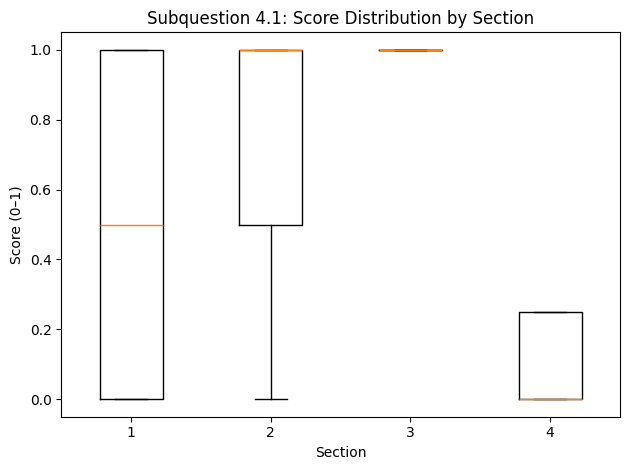

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


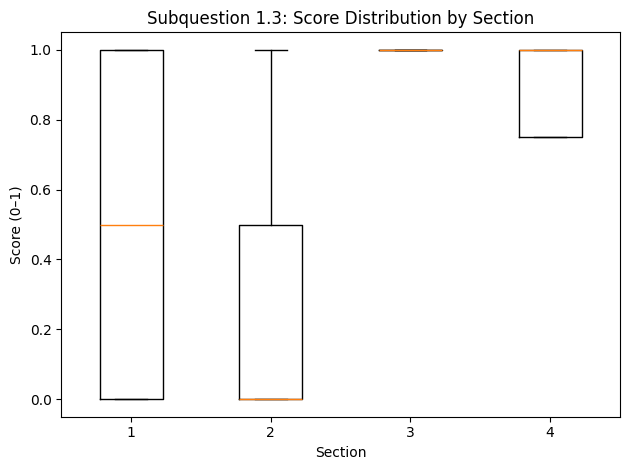

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


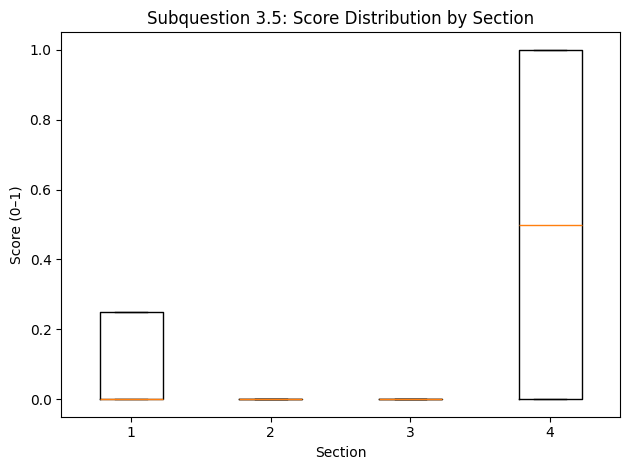

C:\Users\Yzz\AppData\Local\Temp\ipykernel_21872\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


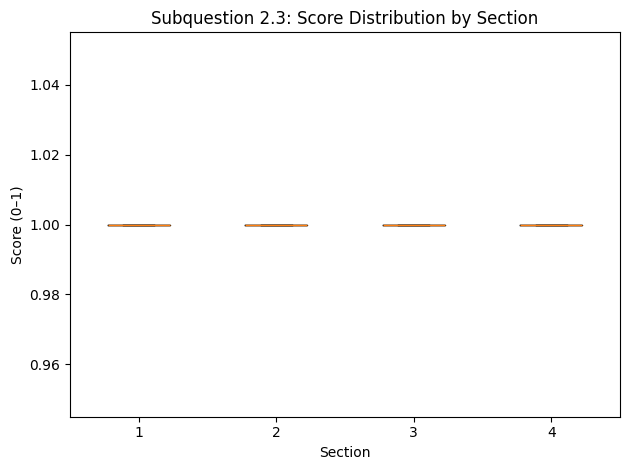

In [38]:
import matplotlib.pyplot as plt

sections = sorted(long_scores_sec["section"].unique())

for sq in interest_subqs["subquestion"]:
    data = [
        long_scores_sec.loc[
            (long_scores_sec["subquestion"] == sq) &
            (long_scores_sec["section"] == sec),
            "score"
        ]
        for sec in sections
    ]
    
    plt.figure()
    plt.boxplot(data, labels=sections, showfliers=False)
    plt.xlabel("Section")
    plt.ylabel("Score (0–1)")
    plt.title(f"Subquestion {sq}: Score Distribution by Section")
    plt.tight_layout()
    plt.show()

### Completeness by group

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df_status = pd.read_csv("status.csv")

print(df_status.shape)
display(df_status.head())

(39, 3)


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [42]:
df_status["completed"] = (
    df_status["completed"]
    .astype(str)
    .str.upper()
    .map({"TRUE": True, "FALSE": False})
)

print("Completed value counts:")
display(df_status["completed"].value_counts(dropna=False))

Completed value counts:


completed
False    26
True     13
Name: count, dtype: int64

In [43]:
completeness_by_section = (
    df_status
    .groupby("section")
    .agg(
        n_total=("completed", "size"),
        n_completed=("completed", "sum"),      # True = 1
        completion_rate=("completed", "mean")  # proportion TRUE
    )
    .reset_index()
)

display(completeness_by_section)

,section,n_total,n_completed,completion_rate
0,1,10,4,0.400000
1,2,10,3,0.300000
2,3,10,2,0.200000
3,4,9,4,0.444444


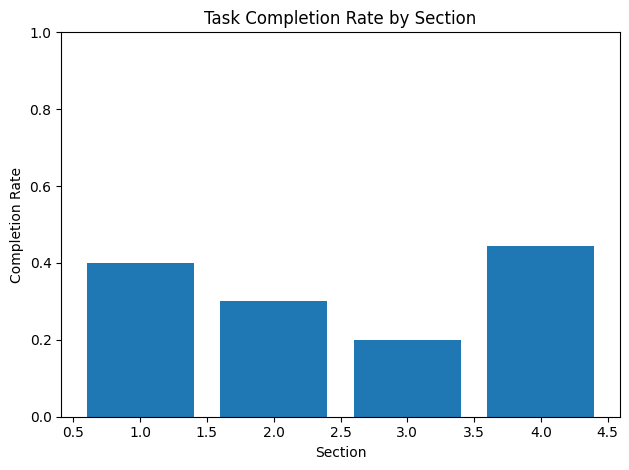

In [44]:
plt.figure()
plt.bar(
    completeness_by_section["section"],
    completeness_by_section["completion_rate"]
)
plt.xlabel("Section")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.title("Task Completion Rate by Section")
plt.tight_layout()
plt.show()